In [14]:
from typing import TypedDict, Annotated, Optional
from langgraph.graph import add_messages, StateGraph, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_tavily import TavilySearch
from langgraph.checkpoint.memory import MemorySaver
from uuid import uuid4
import json

load_dotenv()

model = ChatOpenAI(model="gpt-4o")

In [15]:
search_tool = TavilySearch(max_results=4)

tools = [search_tool]

memory = MemorySaver()

In [16]:
llm_with_tools = model.bind_tools(tools = tools)

response = llm_with_tools.invoke("What is the current weather in bangalore")
response

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 1195, 'total_tokens': 1220, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_de2253e5ef', 'id': 'chatcmpl-DMhbxvOIYFq1sW5fyZp0fRlyX87NR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d1cb6-bfc8-7ba3-81a9-4e81dabfa747-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current weather Bangalore', 'include_domains': ['weather.com']}, 'id': 'call_CmXCbC6yYDOJtlkRlSLfPcSS', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1195, 'output_tokens': 25, 'total_tokens': 1220, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_

In [23]:
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage

class State(TypedDict):
    messages: Annotated[list, add_messages]

async def model(state: State):
    result = await llm_with_tools.ainvoke(state["messages"])
    return {
        "messages": [result], 
    }

async def tools_router(state: State):
    last_message = state["messages"][-1]

    if(hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0):
        return "tool_node"
    else: 
        return END
    
async def tool_node(state):
    """Custom tool node that handles tool calls from the LLM."""
    # Get the tool calls from the last message
    tool_calls = state["messages"][-1].tool_calls
    
    # Initialize list to store tool messages
    tool_messages = []
    
    # Process each tool call
    for tool_call in tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_id = tool_call["id"]
        
        # Handle the search tool
        if tool_name == "tavily_search":
            # Execute the search tool with the provided arguments
            search_results = await search_tool.ainvoke(tool_args)
            
            # Create a ToolMessage for this result
            tool_message = ToolMessage(
                content=str(search_results),
                tool_call_id=tool_id,
                name=tool_name
            )
            
            tool_messages.append(tool_message)
    
    # Add the tool messages to the state
    return {"messages": tool_messages}

graph_builder = StateGraph(State)

graph_builder.add_node("model", model)
graph_builder.add_node("tool_node", tool_node)
graph_builder.set_entry_point("model")

graph_builder.add_conditional_edges("model", tools_router,{
    "tool_node": "tool_node",
     END: END
})
graph_builder.add_edge("tool_node", "model")

graph = graph_builder.compile(checkpointer=memory)

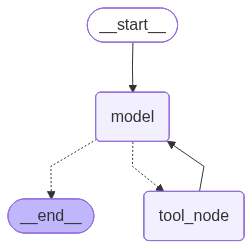

In [24]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

In [27]:
config = {
    "configurable": {
        "thread_id": 69
    }
}

response = await graph.ainvoke({
    "messages": [HumanMessage(content="When is the next spaceX launch?")], 
}, config=config)

response

{'messages': [HumanMessage(content='When is the next spaceX launch?', additional_kwargs={}, response_metadata={}, id='ec7fc1a1-9574-4e22-a7ef-fe994aa503b0'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 1195, 'total_tokens': 1224, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_de2253e5ef', 'id': 'chatcmpl-DMhgjuv0ZoiG7Rc0YOiGiXBPY7xmU', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d1cbb-453e-7580-8baf-2a28168fa4c4-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'next SpaceX launch schedule', 'search_depth': 'advanced', 'topic': 'news'}, 'id': 'call_NJVxPAY26TXTq1Fr7ESc5gMM', 'type': 'tool_call

In [26]:
state = await graph.aget_state(config)
for i, msg in enumerate(state.values["messages"]):
    print(f"[{i}] {type(msg).__name__}: {msg}")

[0] HumanMessage: content='When is the next spaceX launch?' additional_kwargs={} response_metadata={} id='68ff3c53-9232-465b-ba8c-6d3064e03963'
[1] AIMessage: content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 1195, 'total_tokens': 1220, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_de2253e5ef', 'id': 'chatcmpl-DMhdEU9DnxgH2EFjXcwmNgrZlScQV', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d1cb7-f2b9-7e70-8046-01c2e6f315bd-0' tool_calls=[{'name': 'tavily_search', 'args': {'query': 'next SpaceX launch schedule', 'search_depth': 'fast'}, 'id': 'call_SaBKt70uuf38UDU8nn3ua73u', 'type': 'tool_call'}] invalid_tool_calls=[] usage_meta

In [28]:
config = {
    "configurable": {
        "thread_id": 8
    }
}

# Use async for to iterate over the async generator
async for event in graph.astream_events({
    "messages": [HumanMessage(content="When is the next spacex launch?")],
}, config=config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='When is the next spacex launch?', additional_kwargs={}, response_metadata={})]}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019d1cbc-b481-7172-ada1-86c298e69935', 'metadata': {'thread_id': 8}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='When is the next spacex launch?', additional_kwargs={}, response_metadata={}, id='7ce70017-5127-4176-ba9f-568922643605')]}}, 'name': 'model', 'tags': ['graph:step:1'], 'run_id': '019d1cbc-b484-7902-93e9-4a06b3754a5b', 'metadata': {'thread_id': 8, 'langgraph_step': 1, 'langgraph_node': 'model', 'langgraph_triggers': ('branch:to:model',), 'langgraph_path': ('__pregel_pull', 'model'), 'langgraph_checkpoint_ns': 'model:a033a270-185a-d66b-4f6a-86c78f8f5c89'}, 'parent_ids': ['019d1cbc-b481-7172-ada1-86c298e69935']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='When is the next spa